In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('cybersecurity_intrusion_data.csv')
df

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9532,SID_09533,194,ICMP,3,226.049889,AES,0.517737,3,Chrome,0,1
9533,SID_09534,380,TCP,3,182.848475,NaN,0.408485,0,Chrome,0,0
9534,SID_09535,664,TCP,5,35.170248,AES,0.359200,1,Firefox,0,0
9535,SID_09536,406,TCP,4,86.664703,AES,0.537417,1,Chrome,1,0


In [3]:
df.shape

(9537, 11)

In [4]:
df.head(10)

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0
5,SID_00006,453,UDP,5,380.471550,AES,0.422486,2,Chrome,1,0
6,SID_00007,815,ICMP,4,728.107165,AES,0.413772,1,Chrome,0,1
7,SID_00008,653,TCP,3,12.599906,DES,0.097719,3,Chrome,1,1
8,SID_00009,406,TCP,2,542.558895,NaN,0.294580,0,Chrome,1,0
9,SID_00010,608,UDP,6,531.944107,NaN,0.424117,1,Chrome,0,0


In [5]:
# Compute unique values per column and overall
# Unique counts per column (including NaN as distinct)
unique_counts = {col: int(df[col].nunique(dropna=False)) for col in df.columns}
# Unique values per column (as lists)
unique_values = {col: df[col].drop_duplicates(keep='first').tolist() for col in df.columns}

print("Unique counts per column:")
for k, v in unique_counts.items():
    print(f"{k}: {v}")

print("\nSample unique values (up to 10 per column):")
for k, vals in unique_values.items():
    sample = vals[:10]
    print(f"{k}: {sample}")

# Overall unique elements across the entire DataFrame (flattened)
all_values = pd.unique(df.values.ravel())
print("\nTotal unique elements across dataset:", len(all_values))

Unique counts per column:
session_id: 9537
network_packet_size: 959
protocol_type: 3
login_attempts: 13
session_duration: 9532
encryption_used: 3
ip_reputation_score: 9537
failed_logins: 6
browser_type: 5
unusual_time_access: 2
attack_detected: 2

Sample unique values (up to 10 per column):
session_id: ['SID_00001', 'SID_00002', 'SID_00003', 'SID_00004', 'SID_00005', 'SID_00006', 'SID_00007', 'SID_00008', 'SID_00009', 'SID_00010']
network_packet_size: [599, 472, 629, 804, 453, 815, 653, 406, 608, 407]
protocol_type: ['TCP', 'UDP', 'ICMP']
login_attempts: [4, 3, 5, 2, 6, 9, 8, 1, 7, 10]
session_duration: [492.9832634426563, 1557.9964611204384, 75.04426166420741, 601.2488351708328, 532.5408884201419, 380.4715502453134, 728.1071646972356, 12.5999060098958, 542.5588952208974, 531.9441066211396]
encryption_used: ['DES', 'AES', nan]
ip_reputation_score: [0.606818080396889, 0.3015689675960893, 0.7391643279163831, 0.1232671757524846, 0.0548738567431703, 0.4224858607066699, 0.4137719285892984, 

In [6]:
df.isnull().sum()

session_id                0
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
import numpy as np

In [9]:
df.head()

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
from sklearn import metrics
from sklearn import svm


In [11]:
for col in ['encryption_used']:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

session_id             0
network_packet_size    0
protocol_type          0
login_attempts         0
session_duration       0
encryption_used        0
ip_reputation_score    0
failed_logins          0
browser_type           0
unusual_time_access    0
attack_detected        0
dtype: int64


In [12]:
df = df.drop('session_id', axis=1)

categorical_columns = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

X = df.drop('attack_detected', axis=1)
y = df['attack_detected']


In [13]:
X.head()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,protocol_type_TCP,protocol_type_UDP,encryption_used_DES,browser_type_Edge,browser_type_Firefox,browser_type_Safari,browser_type_Unknown
0,599,4,492.983263,0.606818,1,0,True,False,True,True,False,False,False
1,472,3,1557.996461,0.301569,0,0,True,False,True,False,True,False,False
2,629,3,75.044262,0.739164,2,0,True,False,True,False,False,False,False
3,804,4,601.248835,0.123267,0,0,False,True,True,False,False,False,True
4,453,5,532.540888,0.054874,1,0,True,False,False,False,True,False,False


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
logr = LogisticRegression(max_iter=1000)
logr.fit(X_train_scaled, y_train)

# Prediction
y_pred = logr.predict(X_test_scaled)
train_accuracy = logr.score(X_train_scaled, y_train)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Train Accuracy: {train_accuracy:.16f}")
print(f"Test Accuracy: {test_accuracy:.16f}")

Train Accuracy: 0.7412504915454188
Test Accuracy: 0.7384696016771488


In [20]:
print("Features:", df.columns.tolist())
print("Target labels:", df['attack_detected'].unique())
print("First 5 records:\n", df.head())
print("Data shape:", df.shape)

Features: ['network_packet_size', 'login_attempts', 'session_duration', 'ip_reputation_score', 'failed_logins', 'unusual_time_access', 'attack_detected', 'protocol_type_TCP', 'protocol_type_UDP', 'encryption_used_DES', 'browser_type_Edge', 'browser_type_Firefox', 'browser_type_Safari', 'browser_type_Unknown']
Target labels: [1 0]
First 5 records:
    network_packet_size  login_attempts  session_duration  ip_reputation_score  \
0                  599               4        492.983263             0.606818   
1                  472               3       1557.996461             0.301569   
2                  629               3         75.044262             0.739164   
3                  804               4        601.248835             0.123267   
4                  453               5        532.540888             0.054874   

   failed_logins  unusual_time_access  attack_detected  protocol_type_TCP  \
0              1                    0                1               True   
1        

In [21]:
dt = DecisionTreeClassifier(max_depth=2, criterion='gini', random_state=44)
dt.fit(X_train_scaled, y_train)
y_pred = dt.predict(X_test_scaled )
train_accuracy=dt.score(X_train_scaled, y_train)
test_accuracy=accuracy_score(y_test, y_pred)
print(f"Train Accuracy: {train_accuracy:.16f}")
print(f"Test Accuracy: {test_accuracy:.16f}")

Train Accuracy: 0.8130816620789094
Test Accuracy: 0.7908805031446541


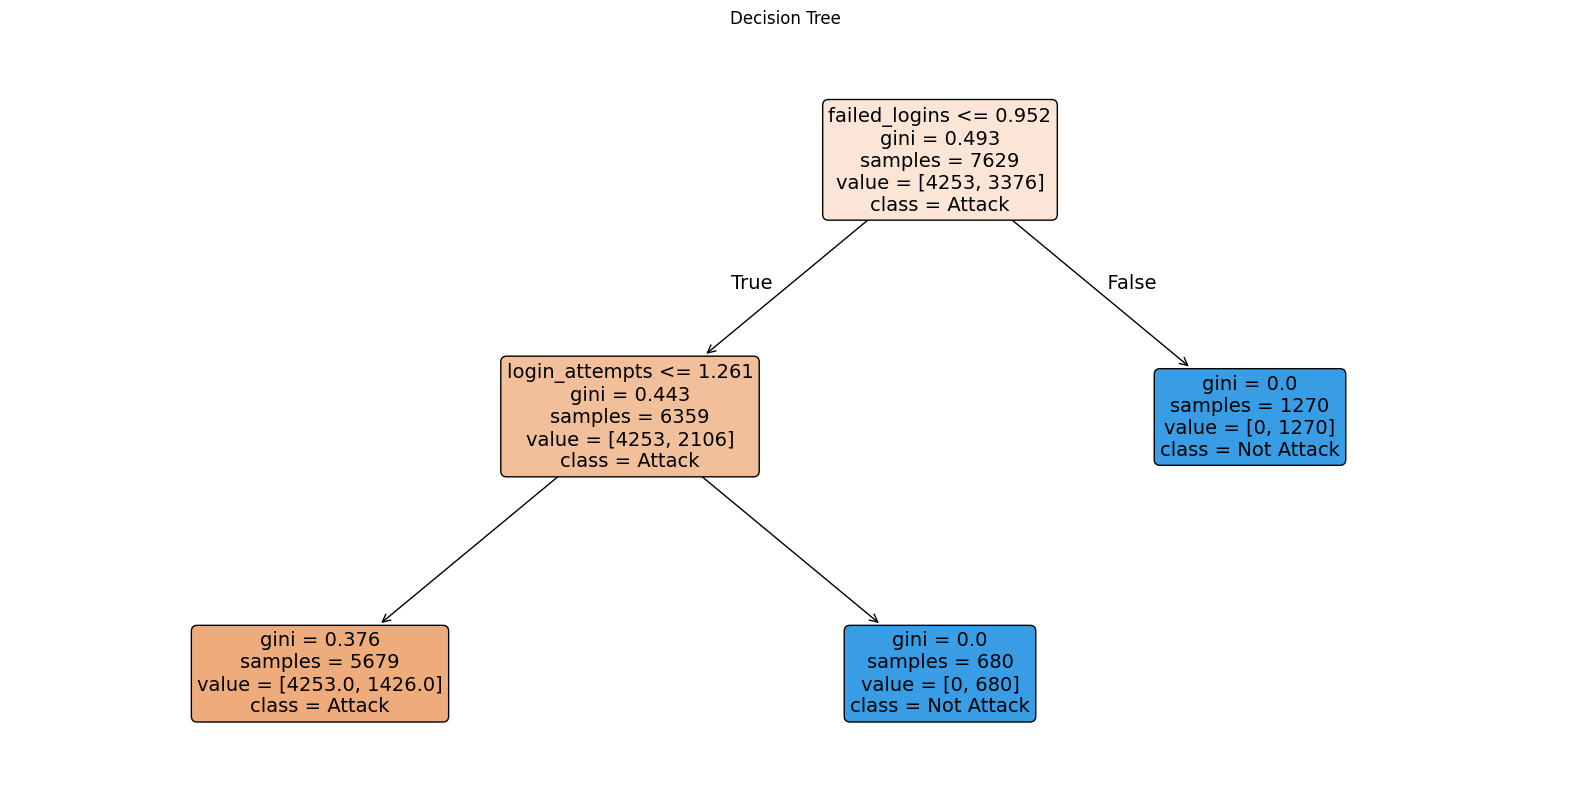

In [22]:
plt.figure(figsize=(20, 10))
plot_tree(dt,
          feature_names=X_train.columns,
          class_names=['Attack', 'Not Attack'],
          filled=True,
          rounded=True,
          fontsize=14)
plt.title("Decision Tree")
plt.show()

In [23]:
rf_model = RandomForestClassifier(random_state=44)
rf_model.fit(X_train_scaled, y_train)


y_pred = rf_model.predict(X_test_scaled )
train_accuracy = rf_model.score(X_train_scaled, y_train)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Train Accuracy: {train_accuracy:.16f}")
print(f"Test Accuracy: {test_accuracy:.16f}")


cm = confusion_matrix(y_test, y_pred)

Train Accuracy: 1.0000000000000000
Test Accuracy: 0.8789308176100629


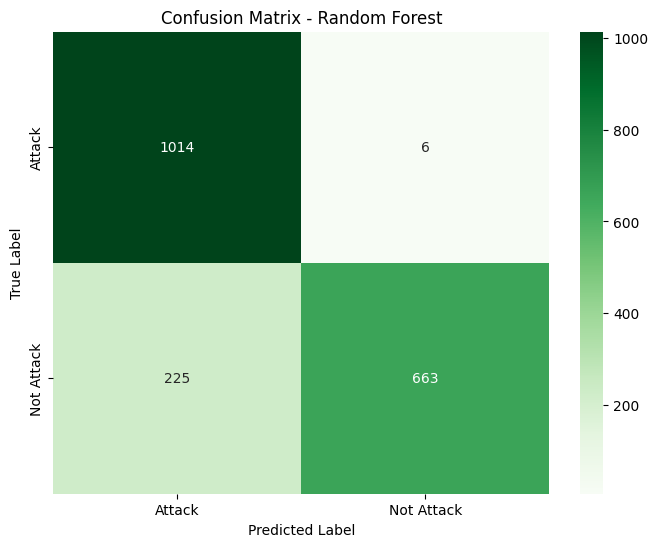

In [24]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Attack', 'Not Attack'], yticklabels=['Attack', 'Not Attack'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [25]:
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall:", metrics.recall_score(y_test, y_pred))

Precision: 0.9910313901345291
Recall: 0.7466216216216216


In [26]:
import pickle

# Assuming 'model' is your trained ML model
with open('rf_model.pkl', 'wb') as file:
        pickle.dump(rf_model, file)

    # To load the model
with open('rf_model.pkl', 'rb') as file:
        loaded_model = pickle.load(file)